# Group 1 — AI Detection Model v4

**Dataset:** 5,000 REAL (Flickr30k) + 5,000 AI (WAI 2025 — Shutterstock quality, modern generators)  
**Fix:** High-resolution AI images from real-world generators — not 32×32 thumbnails  
**Starts from:** v3 weights  
**Runtime:** ~45–60 min on Colab T4 GPU

In [1]:
# Step 1 — Setup: Mount Drive + Kaggle API
from google.colab import files, drive
import os

drive.mount('/content/drive')

uploaded = files.upload()  # Select kaggle.json
filename = list(uploaded.keys())[0]

!pip install kaggle --quiet
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'wb') as f:
    f.write(uploaded[filename])
!chmod 600 ~/.kaggle/kaggle.json

print('Setup complete.')

Mounted at /content/drive


Saving kaggle.json to kaggle.json
Setup complete.


In [2]:
# Step 2 — Download datasets (one command per line — no line-break errors)
import os
os.makedirs('/content/data/raw', exist_ok=True)
os.makedirs('/content/data/processed', exist_ok=True)

print('Downloading Flickr30k real photos...')
!kaggle datasets download -d hsankesara/flickr-image-dataset -p /content/data/raw/ --quiet
!unzip -q -o /content/data/raw/flickr-image-dataset.zip -d /content/data/raw/flickr/
print('Flickr30k done.')

print('Downloading WAI 2025 AI vs Human dataset (~10-15 min)...')
!kaggle datasets download -d alessandrasala79/ai-vs-human-generated-dataset -p /content/data/raw/ --quiet
!unzip -q -o /content/data/raw/ai-vs-human-generated-dataset.zip -d /content/data/raw/aivshuman/
print('WAI 2025 done.')

Dataset URL: https://www.kaggle.com/datasets/hsankesara/flickr-image-dataset
License(s): CC0-1.0
Flickr30k done.
Dataset URL: https://www.kaggle.com/datasets/alessandrasala79/ai-vs-human-generated-dataset
License(s): apache-2.0
WAI 2025 done.


In [12]:
# Step 3 — Check folder structure (so we know the correct paths)
import os
print('=== WAI 2025 folder structure ===')
for root, dirs, files_list in os.walk('/content/data/raw/aivshuman/'):
    depth = root.replace('/content/data/raw/aivshuman/', '').count(os.sep)
    if depth <= 2:
        n = len([f for f in files_list if f.lower().endswith(('.jpg', '.png', '.jpeg', '.webp'))])
        indent = '  ' * depth
        print(f'{indent}{os.path.basename(root)}/  ({n} images)')

print('\n=== Flickr folder structure ===')
for root, dirs, files_list in os.walk('/content/data/raw/flickr/'):
    depth = root.replace('/content/data/raw/flickr/', '').count(os.sep)
    if depth <= 2:
        n = len([f for f in files_list if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
        indent = '  ' * depth
        print(f'{indent}{os.path.basename(root)}/  ({n} images)')

=== WAI 2025 folder structure ===
/  (0 images)
train_data/  (79950 images)
test_data_v2/  (5540 images)

=== Flickr folder structure ===
/  (0 images)
flickr30k_images/  (0 images)
  flickr30k_images/  (31783 images)
    flickr30k_images/  (31783 images)


In [13]:
# Step 4 — Collect image paths
# Uses broad recursive glob to handle any folder structure
import glob

# REAL: Flickr30k
real_paths = glob.glob('/content/data/raw/flickr/**/*.jpg', recursive=True)

# AI: WAI 2025 — find folders with 'ai', 'fake', 'generated', 'artificial' in name
fake_paths = []
for root, dirs, files_list in os.walk('/content/data/raw/aivshuman/'):
    folder = os.path.basename(root).lower()
    if any(k in folder for k in ['ai', 'fake', 'generated', 'artificial', 'synthetic']):
        for f in files_list:
            if f.lower().endswith(('.jpg', '.png', '.jpeg', '.webp')):
                fake_paths.append(os.path.join(root, f))

# If no AI folder found by name, take ALL images from aivshuman as a fallback
if len(fake_paths) == 0:
    print('WARNING: Could not auto-detect AI folder. Using all aivshuman images as AI.')
    fake_paths = glob.glob('/content/data/raw/aivshuman/**/*.jpg', recursive=True)
    fake_paths += glob.glob('/content/data/raw/aivshuman/**/*.png', recursive=True)

print(f'Real photos available:  {len(real_paths):,}')
print(f'AI images available:    {len(fake_paths):,}')

if len(fake_paths) == 0:
    print('\nERROR: No AI images found. Check folder structure in Step 3 output.')

Real photos available:  63,566
AI images available:    79,950


In [14]:
# Step 5 — Clean and balance: 5,000 REAL + 5,000 AI
import hashlib
from PIL import Image
from tqdm import tqdm

def clean_images(paths, label_name, max_samples=5000, min_size=100):
    """Remove corrupted, too-small, and duplicate images."""
    seen_hashes = set()
    clean = []
    for path in tqdm(paths, desc=f'Cleaning {label_name}'):
        try:
            img = Image.open(path).convert('RGB')
            w, h = img.size
            if w < min_size or h < min_size:
                continue
            img_hash = hashlib.md5(img.tobytes()).hexdigest()
            if img_hash in seen_hashes:
                continue
            seen_hashes.add(img_hash)
            clean.append(path)
            if len(clean) >= max_samples:
                break
        except Exception:
            continue
    print(f'{label_name}: {len(clean):,} clean images')
    return clean

# Both capped at 5,000 — perfectly balanced
clean_real = clean_images(real_paths, 'REAL',         max_samples=5000, min_size=100)
clean_fake = clean_images(fake_paths, 'AI_GENERATED', max_samples=5000, min_size=100)

print(f'\nFinal: {len(clean_real):,} REAL + {len(clean_fake):,} AI_GENERATED')

if len(clean_fake) == 0:
    raise ValueError('AI images still 0 — check Step 3 folder output and fix fake_paths in Step 4.')

Cleaning REAL:   0%|          | 132/63566 [00:00<03:52, 272.32it/s]


KeyboardInterrupt: 

In [ ]:
# Step 6 — Train / Val / Test split (70 / 15 / 15)
import pandas as pd
from sklearn.model_selection import train_test_split

real_df = pd.DataFrame({'filepath': clean_real, 'label': 0})
fake_df = pd.DataFrame({'filepath': clean_fake, 'label': 1})
full_df = pd.concat([real_df, fake_df], ignore_index=True).sample(frac=1, random_state=42)

train_df, temp_df = train_test_split(full_df, test_size=0.30, stratify=full_df['label'], random_state=42)
val_df,   test_df = train_test_split(temp_df,  test_size=0.50, stratify=temp_df['label'],  random_state=42)

train_df.to_csv('/content/data/processed/train.csv', index=False)
val_df.to_csv('/content/data/processed/val.csv',     index=False)
test_df.to_csv('/content/data/processed/test.csv',   index=False)

print(f'Train: {len(train_df):,}  ({train_df.label.value_counts()[0]:,} REAL, {train_df.label.value_counts()[1]:,} AI)')
print(f'Val:   {len(val_df):,}   ({val_df.label.value_counts()[0]:,} REAL, {val_df.label.value_counts()[1]:,} AI)')
print(f'Test:  {len(test_df):,}   ({test_df.label.value_counts()[0]:,} REAL, {test_df.label.value_counts()[1]:,} AI)')

In [ ]:
# Step 7 — Dataset class and DataLoaders
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class ImageDataset(Dataset):
    """Loads images from a CSV manifest (filepath, label)."""
    def __init__(self, csv_path, transform=None):
        self.df = pd.read_csv(csv_path)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['filepath']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, int(row['label'])

train_dataset = ImageDataset('/content/data/processed/train.csv', transform=train_transform)
val_dataset   = ImageDataset('/content/data/processed/val.csv',   transform=val_transform)
test_dataset  = ImageDataset('/content/data/processed/test.csv',  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print('Dataset is balanced 50/50 — no sampler needed')

In [ ]:
# Step 8 — Load v3 weights as starting point
import torch
import torch.nn as nn
import torchvision.models as models

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

V3_WEIGHTS = '/content/drive/MyDrive/efficientnet_b0_v3.pth'

def build_model():
    model = models.efficientnet_b0(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2, inplace=True),
        nn.Linear(in_features, 2),
    )
    return model

model = build_model()
model.load_state_dict(torch.load(V3_WEIGHTS, map_location=device, weights_only=True))
model = model.to(device)
print('v3 weights loaded successfully.')

In [9]:
# Step 9 — Fine-tune on new dataset (save v4 to Drive)
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

for param in model.parameters():
    param.requires_grad = True

EPOCHS   = 8
LR       = 2e-5
PATIENCE = 3

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()  # Balanced dataset — no weighting needed

SAVE_PATH = '/content/drive/MyDrive/efficientnet_b0_v4.pth'
best_val_acc = 0.0
patience_counter = 0
history = []

def evaluate(loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            correct += (model(images).argmax(dim=1) == labels).sum().item()
            total += labels.size(0)
    return correct / total

print(f'Training v4 for up to {EPOCHS} epochs...\n')

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if (batch_idx + 1) % 50 == 0:
            print(f'  Epoch {epoch} | Batch {batch_idx+1}/{len(train_loader)} | Loss: {running_loss/(batch_idx+1):.4f}')

    scheduler.step()
    train_loss = running_loss / len(train_loader)
    val_acc    = evaluate(val_loader)
    history.append({'epoch': epoch, 'train_loss': train_loss, 'val_acc': val_acc})
    print(f'Epoch {epoch}/{EPOCHS} — Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), SAVE_PATH)
        print(f'  Best model saved to Drive (val_acc={best_val_acc:.4f})')
    else:
        patience_counter += 1
        print(f'  No improvement. Patience: {patience_counter}/{PATIENCE}')
        if patience_counter >= PATIENCE:
            print('Early stopping triggered.')
            break

print(f'\nDone. Best val accuracy: {best_val_acc:.4f}')

Training v4 for up to 8 epochs...

  Epoch 1 | Batch 50/219 | Loss: 0.6573
  Epoch 1 | Batch 100/219 | Loss: 0.5480
  Epoch 1 | Batch 150/219 | Loss: 0.4571
  Epoch 1 | Batch 200/219 | Loss: 0.4156
Epoch 1/8 — Loss: 0.4062 | Val Acc: 0.9180
  Best model saved to Drive (val_acc=0.9180)
  Epoch 2 | Batch 50/219 | Loss: 0.2185
  Epoch 2 | Batch 100/219 | Loss: 0.2194
  Epoch 2 | Batch 150/219 | Loss: 0.2142
  Epoch 2 | Batch 200/219 | Loss: 0.2123
Epoch 2/8 — Loss: 0.2088 | Val Acc: 0.9373
  Best model saved to Drive (val_acc=0.9373)
  Epoch 3 | Batch 50/219 | Loss: 0.1693
  Epoch 3 | Batch 100/219 | Loss: 0.1746
  Epoch 3 | Batch 150/219 | Loss: 0.1700
  Epoch 3 | Batch 200/219 | Loss: 0.1698
Epoch 3/8 — Loss: 0.1706 | Val Acc: 0.9500
  Best model saved to Drive (val_acc=0.9500)
  Epoch 4 | Batch 50/219 | Loss: 0.1583
  Epoch 4 | Batch 100/219 | Loss: 0.1498
  Epoch 4 | Batch 150/219 | Loss: 0.1584
  Epoch 4 | Batch 200/219 | Loss: 0.1543
Epoch 4/8 — Loss: 0.1518 | Val Acc: 0.9480
  No i

=== Classification Report ===
              precision    recall  f1-score   support

        REAL       0.96      0.96      0.96       750
AI_GENERATED       0.96      0.96      0.96       750

    accuracy                           0.96      1500
   macro avg       0.96      0.96      0.96      1500
weighted avg       0.96      0.96      0.96      1500



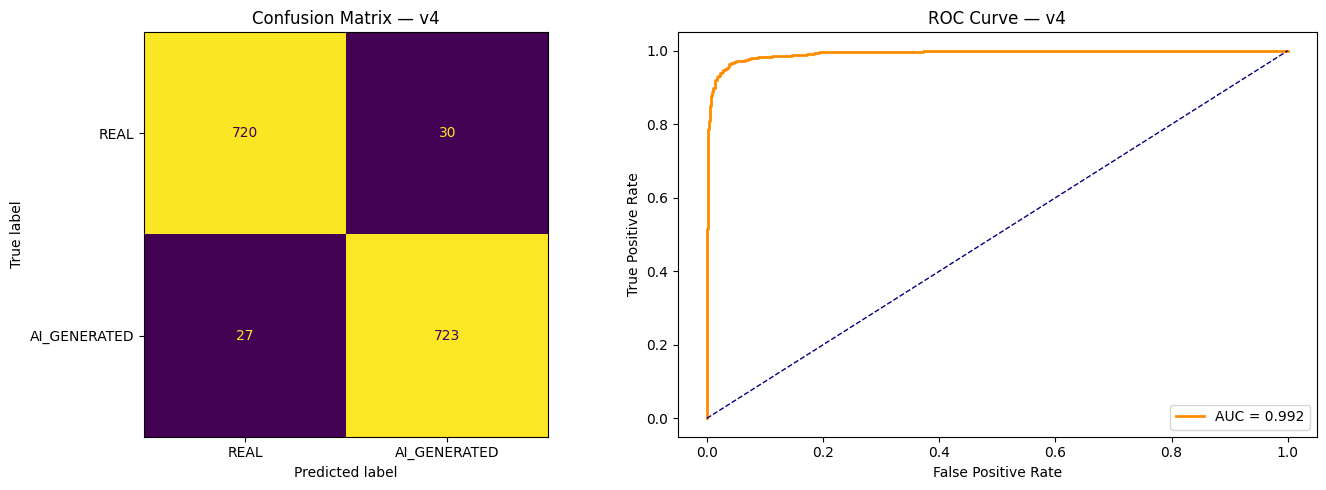

AUC: 0.9924


In [10]:
# Step 10 — Evaluate: confusion matrix, classification report, ROC curve
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, ConfusionMatrixDisplay

model.load_state_dict(torch.load(SAVE_PATH, map_location=device, weights_only=True))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        probs = F.softmax(model(images.to(device)), dim=1)
        all_preds.extend(probs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

print('=== Classification Report ===')
print(classification_report(all_labels, all_preds, target_names=['REAL', 'AI_GENERATED']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(confusion_matrix(all_labels, all_preds),
                       display_labels=['REAL', 'AI_GENERATED']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix — v4')

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'navy', lw=1, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — v4')
axes[1].legend(loc='lower right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/v4_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'AUC: {roc_auc:.4f}')

In [17]:
# Step 11 — Manual test: upload real and AI images to verify
from google.colab import files
from PIL import Image
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms

device = 'cuda' if torch.cuda.is_available() else 'cpu'
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print('Upload images to test (real or AI-generated):')
uploaded = files.upload()

for filename, content in uploaded.items():
    with open('/tmp/test_img.png', 'wb') as f:
        f.write(content)
    tensor = val_transform(Image.open('/tmp/test_img.png').convert('RGB')).unsqueeze(0).to(device)
    with torch.no_grad():
        probs   = F.softmax(model(tensor), dim=1)
        ai_prob = float(probs[0][1])
        label   = 'AI_GENERATED' if ai_prob >= 0.50 else 'REAL'
        conf    = ai_prob if label == 'AI_GENERATED' else float(probs[0][0])
    print(f'{filename}: {label} ({conf*100:.1f}% confidence)')

Upload images to test (real or AI-generated):


Saving DSC_0554.jpg to DSC_0554.jpg
DSC_0554.jpg: AI_GENERATED (96.8% confidence)


## Done — Deploy v4

1. Download `efficientnet_b0_v4.pth` from Google Drive
2. Copy to `backend/model/weights/efficientnet_b0_v4.pth`
3. `efficientnet_model.py` → change `MODEL_PATH` to `efficientnet_b0_v4.pth`
4. `config.py` → change `MODEL_VERSION` to `efficientnet-b0-v4`
5. Restart FastAPI backend